In [39]:
# !pip install astropy
# !pip install scikit-image

import os

from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

import re
from astropy.wcs import WCS

from skimage.draw import ellipse

In [40]:

fits_path = "../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits"

hdul = fits.open(fits_path)
hdul.info()

Filename: ../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     265   ()      
  1  SCI           1 ImageHDU        75   (2380, 1177)   float32   
  2  ERR           1 ImageHDU        10   (2380, 1177)   float32   
  3  CON           1 ImageHDU        10   (2380, 1177, 1)   int32   
  4  WHT           1 ImageHDU         9   (2380, 1177)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2380, 1177)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2380, 1177)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2380, 1177)   float32   
  8  HDRTAB        1 BinTableHDU    502   12R x 246C   [23A, 5A, 3A, 48A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 32A, 50A, 70A, 11A, 2A, 47A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 12A, 6A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 7A, 7A, 5A, D, D, D, D, D, D, 27A, D, D, 4A, 8A, 5A, 4A, 3A, 4A, K, 5A, 9A, D, D, D, D, D

In [41]:
data = hdul[1].data
header = hdul[1].header

In [42]:
print(data.shape)
print(np.nanmin(data), np.nanmax(data))
print(header)

(1177, 2380)
7.1088414 411.28107
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2380                                                  NAXIS2  =                 1177                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'SCI     '           / extension name                                 MJD-BEG =     59777.4644468287 / [d] exposure start time in MJD                 MJD-AVG =    59777.50131464893 / [d] exposure mid-point in MJD                  MJD-END =   59777.538032592594 / [d] exposure end time in MJD                   TDB-BEG =   59777.464825825205 / [d] TDB time of exposure start in MJD          TDB-MID

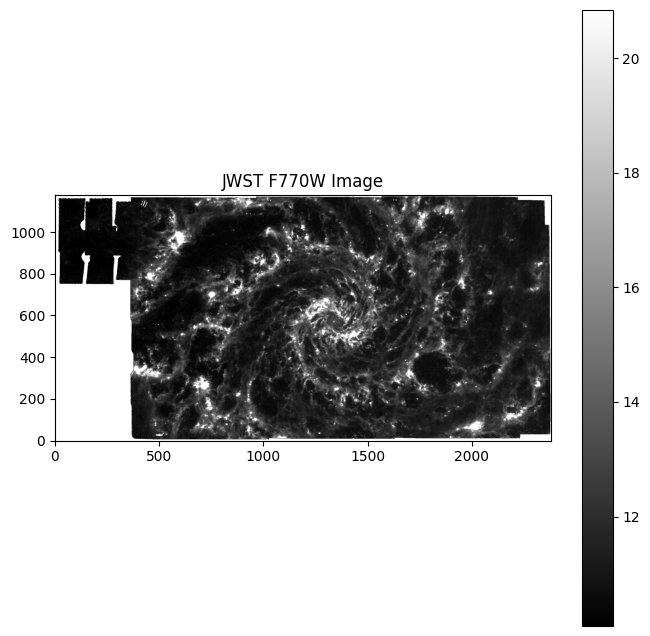

In [84]:
plt.figure(figsize=(8, 8))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.colorbar()
plt.title("JWST F770W Image")
plt.show()

In [44]:
data_clean = np.nan_to_num(data, nan=0.0)

In [45]:
p1, p99 = np.percentile(data_clean, (1, 99))
data_clipped = np.clip(data_clean, p1, p99)

data_norm = (data_clipped - p1) / (p99 - p1)

In [46]:
print (data_norm.shape)
print (data_norm.max())

(1177, 2380)
1.0


In [47]:
# saving ngc 628 png file

# Does directory exist?
os.makedirs("../data/processed/images", exist_ok=True)

# Saving normalized image
np.save("../data/processed/images/ngc628_f770w_norm.npy", data_norm)

In [50]:
# now sanity check

loaded = np.load("../data/processed/images/ngc628_f770w_norm.npy")
print(loaded.shape, loaded.min(), loaded.max())

(1177, 2380) 0.0 1.0


In [53]:
import pandas as pd

df = pd.read_csv("../data/raw/catalogue/jwst_bubble_properties_A.txt")

print(df.head())
print(df.columns)

   ID       RA_DMS      DEC_DMS  SEMI_MAJ_PC  SEMI_MIN_PC  AVG_RAD_PC  PA_DEG  \
0   1  24d08m55.9s   15d48m7.9s           86           86          86       0   
1   2  24d08m56.7s   15d48m2.9s           24           24          24       0   
2   3  24d08m57.0s   15d48m9.0s           42           42          42       0   
3   4  24d08m58.0s  15d47m44.9s           25           25          25       0   
4   5  24d08m58.2s   15d48m2.6s           24           24          24       0   

   ARM  DIST_ARM_PC  GAL_RAD_KPC  
0    3          145         5.22  
1    3          127         5.05  
2    3          138         5.21  
3    3          101         4.54  
4    3          114         4.98  
Index(['ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC', 'AVG_RAD_PC',
       'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC'],
      dtype='str')


In [54]:
print(df.columns)

Index(['ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC', 'AVG_RAD_PC',
       'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC'],
      dtype='str')


In [55]:
df.head()

,ID,RA_DMS,DEC_DMS,SEMI_MAJ_PC,SEMI_MIN_PC,AVG_RAD_PC,PA_DEG,ARM,DIST_ARM_PC,GAL_RAD_KPC
0,1,24d08m55.9s,15d48m7.9s,86,86,86,0,3,145,5.22
1,2,24d08m56.7s,15d48m2.9s,24,24,24,0,3,127,5.05
2,3,24d08m57.0s,15d48m9.0s,42,42,42,0,3,138,5.21
3,4,24d08m58.0s,15d47m44.9s,25,25,25,0,3,101,4.54
4,5,24d08m58.2s,15d48m2.6s,24,24,24,0,3,114,4.98


In [56]:

wcs = WCS(header)
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 24.171680195437894 15.788156932392056
CRPIX : 1176.2406743555237 589.0158147454987
PC1_1 PC1_2  : 0.3421816464879256 -0.939633822723944
PC2_1 PC2_2  : -0.939633822723944 -0.3421816464879256
CDELT : 3.08127265990853e-05 3.08127265990853e-05
NAXIS : 2380  1177


Set DATE-AVG to '2022-07-17T12:01:53.586' from MJD-AVG.
Set DATE-END to '2022-07-17T12:54:46.016' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.754891 from OBSGEO-[XYZ].
Set OBSGEO-H to 1738895745.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [57]:

ra_dms = df['RA_DMS'].tolist()      # degree to dms
dec_dms = df['DEC_DMS'].tolist()

def ra_dec_to_deg(ra_str, dec_str):
    ra_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    dec_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    ra_deg, ra_min, ra_sec = map(float, ra_pattern.match(ra_str).groups())
    dec_deg, dec_min, dec_sec = map(float, dec_pattern.match(dec_str).groups())
    ra_decimal = ra_deg + ra_min / 60 + ra_sec / 3600
    dec_decimal = dec_deg + dec_min / 60 + dec_sec / 3600

    return ra_decimal, dec_decimal

def deg_to_dec(data_in_str):
    data_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    data_deg, data_min, data_sec = map(float, data_pattern.match(data_in_str).groups())
    data_in_decimal = data_deg + data_min / 60 + data_sec / 3600

    return data_in_decimal


ra_degrees = np.zeros(len(df), dtype=float)
dec_degrees = np.zeros(len(df), dtype=float)
for i, row in df.iterrows():
    ra_deg, dec_deg = ra_dec_to_deg(row['RA_DMS'], row['DEC_DMS'])
    ra_degrees[i] = ra_deg
    dec_degrees[i] = dec_deg


In [58]:
# x_pix, y_pix = wcs.world_to_pixel_values(ra, dec)
x_pix, y_pix = wcs.all_world2pix(ra_degrees, dec_degrees, 0)


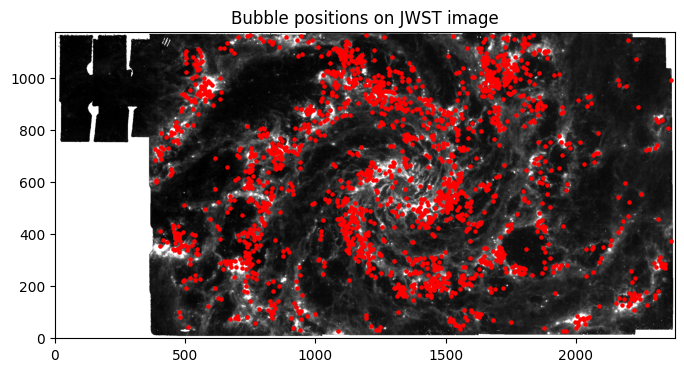

In [59]:
# sanity check  

plt.figure(figsize=(8, 8))
# plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

plt.scatter(x_pix, y_pix, s=5, color='red')
plt.title("Bubble positions on JWST image")

plt.show()

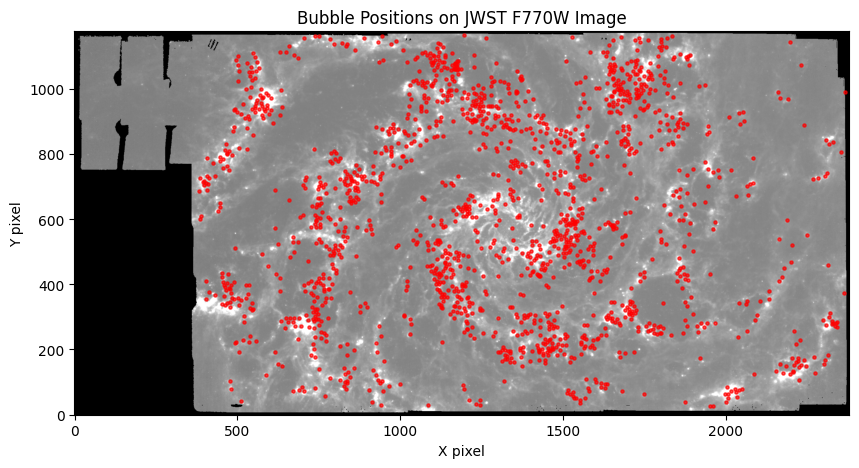

In [86]:
# saving bubble position overlay png file

os.makedirs("../outputs/figures", exist_ok=True)

plt.figure(figsize=(10, 10))
plt.imshow(data_norm, origin="lower", cmap="gray")
plt.scatter(x_pix, y_pix, s=5, color="red", alpha=0.7)
plt.title("Bubble Positions on JWST F770W Image")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")

plt.savefig(
    "../outputs/figures/ngc628_f770w_bubble_positions_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
# mask generation :  parsec to pixel


# Distance to NGC 628 in parsecs
distance_pc = 9.77e6

# Pixel scale from FITS header
pixel_scale_deg = abs(header['CDELT1'])
pixel_scale_arcsec = pixel_scale_deg * 3600

# Physical scale
pc_per_arcsec = distance_pc / 206265
pc_per_pixel = pixel_scale_arcsec * pc_per_arcsec

print("pc per pixel:", pc_per_pixel)

pc per pixel: 5.254140159227344


In [61]:
# semi major and semi minor conversion

semi_major_pix = df['SEMI_MAJ_PC'] / pc_per_pixel
semi_minor_pix = df['SEMI_MIN_PC'] / pc_per_pixel
pa_deg = df['PA_DEG']

In [62]:
mask = np.zeros(data_norm.shape, dtype=np.uint8)     # empty binary mask

In [63]:

height, width = mask.shape

for i in range(len(df)):
    x0 = x_pix[i]
    y0 = y_pix[i]

    a = semi_major_pix.iloc[i]
    b = semi_minor_pix.iloc[i]
    pa = np.deg2rad(pa_deg.iloc[i])

    if np.isnan(x0) or np.isnan(y0) or np.isnan(a) or np.isnan(b):
        continue

    rr, cc = ellipse(
        r=y0,
        c=x0,
        r_radius=b,
        c_radius=a,
        rotation=pa,
        shape=mask.shape
    )

    mask[rr, cc] = 1

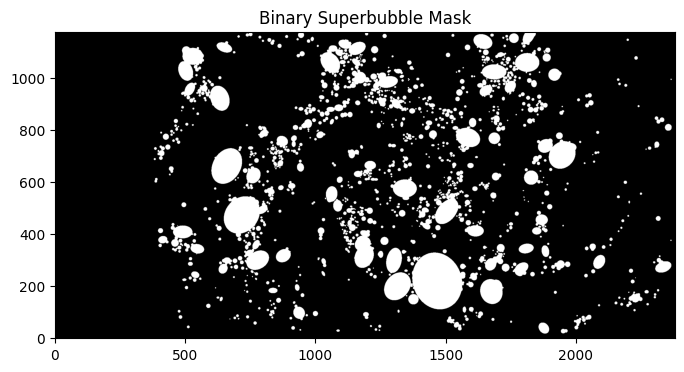

In [64]:
plt.figure(figsize=(8, 8))
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("Binary Superbubble Mask")
plt.show()

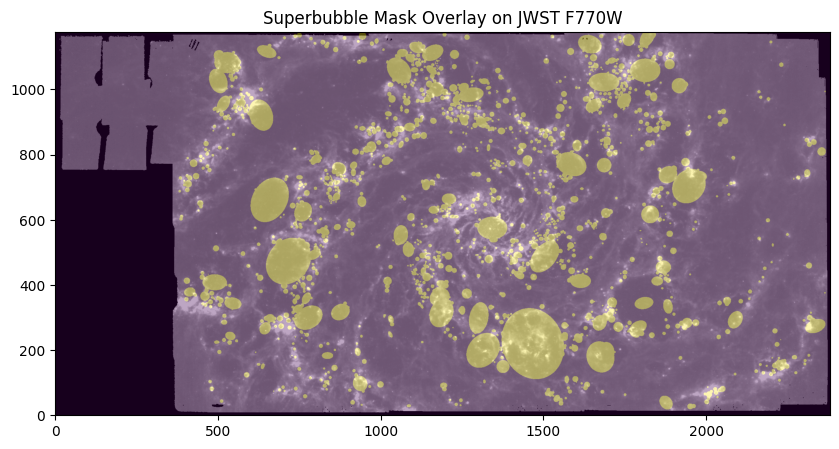

In [65]:
plt.figure(figsize=(10, 10))
plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(mask, origin="lower", alpha=0.35)
plt.title("Superbubble Mask Overlay on JWST F770W")
plt.show()

In [70]:
os.makedirs("../data/processed/masks", exist_ok=True)

np.save("../data/processed/masks/ngc628_superbubble_mask.npy", mask)

In [71]:
loaded = np.load("../data/processed/masks/ngc628_superbubble_mask.npy")
print(loaded.shape, loaded.min(), loaded.max())

(1177, 2380) 0 1


In [87]:
plt.imsave(
    "../outputs/figures/ngc628_f770w_norm.png",
    data_norm, 
    cmap="gray"
)

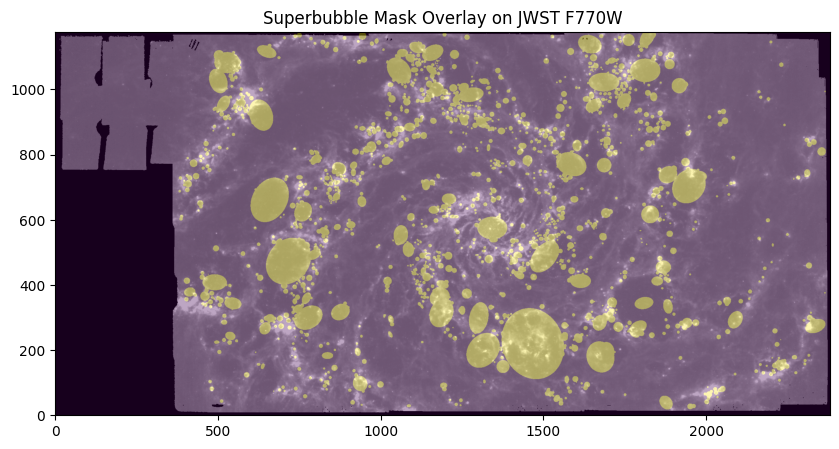

In [88]:
# saving mask overlay png file

plt.figure(figsize=(10, 10))
plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(mask, origin="lower", alpha=0.35)
plt.title("Superbubble Mask Overlay on JWST F770W")
plt.savefig(
    "../outputs/figures/ngc628_superbubble_mask_overlay.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()